# Sprint 4 — Integración, Validación de MVP y Métricas de Negocio

**Módulo:** Módulo 13 - Scrum e IA Aplicada  
**Caso de Estudio:** Caso 3 — Identificación de Clientes Premium  
**Entregables del Sprint 4:**
1. **S4-DE-01 | Dockerizar y operar pipeline reutilizado**: Flujo batch sobre holdout y alineación de features.
2. **S4-DS-01 | Insumos analíticos del MVP**: Definición oficial del criterio de decisión y muestra demo.
3. **S4-DS-02 | Explicabilidad y SHAP**: Explicabilidad a nivel de feature importance global y local (SHAP nativo).
4. **S4-DS-03 | Consolidación de métricas de negocio**: Conversión a KPIs de negocio y simulación de ROI de campaña.

Este notebook consolida y ejecuta estas actividades sobre el conjunto de datos de holdout mensual (`holdout_3m`).

In [1]:
from __future__ import annotations

import json
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

sns.set_theme(style='whitegrid')

# ── Configuración de Rutas ──────────────────────────────────────────────────
project_root = Path.cwd().resolve()
if not (project_root / 'data').exists():
    for candidate in [project_root, *project_root.parents]:
        if (candidate / 'data').exists() and (candidate / 'notebooks').exists():
            project_root = candidate
            break

HOLDOUT_RFM_PATH    = project_root / 'data' / 'processed' / 'holdout_features_rfm.parquet'
HOLDOUT_CLEAN_PATH  = project_root / 'data' / 'processed' / '03_master_table_clean_holdout.parquet'
METADATA_PATH       = project_root / 'data' / 'processed' / '06_features_selected_metadata.json'
MODEL_PATH          = project_root / 'models' / 'final' / 'modelo_final.pkl'
SELECTED_OUT_PATH   = project_root / 'data' / 'processed' / 'holdout_features_selected.parquet'
DEMO_SAMPLE_PATH    = project_root / 'data' / 'processed' / 'demo_sample_scoring.parquet'
FIGURES_DIR         = project_root / 'reports' / 'figures'

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f'Proyecto: {project_root}')

Proyecto: /home/gerick/Documents/MIADAS/miadas_mod_13_scrum


## 1. S4-DE-01 | Alineación de Features y Preparación de `holdout_features_selected.parquet`

Para garantizar que el pipeline sea compatible con el modelo entrenado, leemos las variables RFM calculadas en holdout y las alineamos (filtramos y ordenamos) según las columnas seleccionadas oficialmente en el Sprint 3 (registradas en `06_features_selected_metadata.json`).

In [2]:
# Cargar variables RFM de holdout y la metadata del modelo
rfm_df = pd.read_parquet(HOLDOUT_RFM_PATH)
with open(METADATA_PATH) as f:
    metadata = json.load(f)

selected_features = metadata['selected_model_columns']
print(f'Holdout RFM crudo: {rfm_df.shape}')
print(f'Features seleccionadas por el modelo: {len(selected_features)}')

# Comprobar que no falte ninguna feature en holdout
missing_features = [col for col in selected_features if col not in rfm_df.columns]
print(f'Features faltantes en holdout: {missing_features}')
assert len(missing_features) == 0, '¡Error! Faltan features requeridas en el dataset de holdout.'

# Alinear columnas: conservamos identificador, target y las features seleccionadas en el orden correcto
aligned_columns = ['customer_unique_id', 'is_premium'] + selected_features
holdout_selected_df = rfm_df[aligned_columns].copy()
print(f'Dataset alineado holdout_features_selected: {holdout_selected_df.shape}')

# Guardar el artefacto final
holdout_selected_df.to_parquet(SELECTED_OUT_PATH, index=False)
print(f'Artefacto guardado exitosamente en: {SELECTED_OUT_PATH}')

Holdout RFM crudo: (96096, 51)
Features seleccionadas por el modelo: 28
Features faltantes en holdout: []
Dataset alineado holdout_features_selected: (96096, 30)
Artefacto guardado exitosamente en: /home/gerick/Documents/MIADAS/miadas_mod_13_scrum/data/processed/holdout_features_selected.parquet


## 2. S4-DS-01 | Carga del Modelo Oficial y Validación de Incompatibilidades

Cargamos el pipeline serializado en `modelo_final.pkl` y ejecutamos la inferencia sobre el dataset de holdout para validar la compatibilidad operativa de las columnas y del entorno.

In [3]:
# Cargar el modelo final serializado (.pkl)
with open(MODEL_PATH, 'rb') as f:
    pipeline = pickle.load(f)

print('Modelo final cargado exitosamente.')
print(pipeline)

# Separar features y target para evaluación
X_holdout = holdout_selected_df[selected_features]
y_holdout = holdout_selected_df['is_premium']

# Ejecutar la predicción de probabilidades y clases con el umbral por defecto (0.50)
probs_holdout = pipeline.predict_proba(X_holdout)[:, 1]
preds_holdout_50 = (probs_holdout >= 0.50).astype(int)

print('\nInferencia ejecutada con éxito.')
print(f'Clientes evaluados en holdout: {len(X_holdout)}')
print(f'Tasa de clientes Premium predicha (umbral 0.50): {preds_holdout_50.mean():.2%}')
print(f'Tasa de clientes Premium real: {y_holdout.mean():.2%}')

Modelo final cargado exitosamente.
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['total_orders',
                                                   'total_items',
                                                   'total_products',
                                                   'avg_review_score',
                                                   'avg_delivery_days',
                                                   'avg_estimated_delivery_days',
                                                   'delivered_orders',
                                                   'late_deliveries',
                                                   'payment_methods_count',
                                                 


Inferencia ejecutada con éxito.
Clientes evaluados en holdout: 96096
Tasa de clientes Premium predicha (umbral 0.50): 2.04%
Tasa de clientes Premium real: 1.30%


/home/gerick/miniforge3/envs/ai-miadas/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 3. S4-DS-01 | Preparación de Insumos Analíticos para la Demo (Muestra Demo)

Definimos el criterio oficial de decisión (`predict_proba() >= 0.55`) y extraemos una muestra controlada con casos reales representativos del segmento Premium y Regular para la demostración en vivo (MVP Dashboard).

In [4]:
best_threshold = 0.55
preds_holdout_55 = (probs_holdout >= best_threshold).astype(int)

# Unimos las probabilidades y predicciones al DataFrame
demo_df = holdout_selected_df.copy()
demo_df['premium_probability'] = probs_holdout
demo_df['predicted_premium'] = preds_holdout_55

# Identificamos casos:
# - True Premium (TP): Real 1, Predicho 1 (alta confianza)
# - True Regular (TN): Real 0, Predicho 0 (alta confianza)
tp_cases = demo_df[(demo_df['is_premium'] == 1) & (demo_df['predicted_premium'] == 1)].sort_values('premium_probability', ascending=False).head(2)
tn_cases = demo_df[(demo_df['is_premium'] == 0) & (demo_df['predicted_premium'] == 0)].sort_values('premium_probability', ascending=True).head(2)

# Combinamos en una muestra demo de 4 casos representativos
demo_sample = pd.concat([tp_cases, tn_cases])
print(f'Casos Demo seleccionados (2 True Premium, 2 True Regular):')
display_cols = ['customer_unique_id', 'is_premium', 'predicted_premium', 'premium_probability', 'total_orders', 'recency_days', 'customer_lifetime_days']
print(demo_sample[display_cols].to_string(index=False))

# Guardamos la muestra demo
demo_sample.to_parquet(DEMO_SAMPLE_PATH, index=False)
demo_sample[display_cols].to_csv(project_root / 'data' / 'processed' / 'demo_cases.csv', index=False)
print(f'Muestra demo guardada en: {DEMO_SAMPLE_PATH}')

Casos Demo seleccionados (2 True Premium, 2 True Regular):
              customer_unique_id  is_premium  predicted_premium  premium_probability  total_orders  recency_days  customer_lifetime_days
08a374bca4063116d5530a7b04ecaf3f           1                  1             0.992563           2.0          65.0                     0.0
c8ed31310fc440a3f8031b177f9842c3           1                  1             0.990987           1.0          66.0                     0.0
91544d22848a922381b73b5e21ad58ff           0                  0             0.002051           2.0          48.0                    23.0
e09cb1f5fa66176de2bba83e6a74de84           0                  0             0.002080           1.0          74.0                     0.0
Muestra demo guardada en: /home/gerick/Documents/MIADAS/miadas_mod_13_scrum/data/processed/demo_sample_scoring.parquet


## 4. S4-DS-02 | Explicabilidad y SHAP Nativos de LightGBM

Dado que no disponemos de la librería `shap` instalada, aprovechamos la capacidad nativa de LightGBM para calcular las contribuciones locales de variables (SHAP values) sobre el espacio preprocesado (una vez aplicado ColumnTransformer) de los casos demo.

In [5]:
preprocessor = pipeline.named_steps['preprocessor']
lgb_model = pipeline.named_steps['model']

# Preprocesamos las características de la muestra demo
X_demo = demo_sample[selected_features]
X_demo_proc = preprocessor.transform(X_demo)
feature_names_out = preprocessor.get_feature_names_out()

# Calculamos las contribuciones locales (pred_contrib=True)
# Devuelve una matriz de shape (4, n_features_out + 1)
contribs = lgb_model.predict(X_demo_proc, pred_contrib=True)
shap_values = contribs[:, :-1]
base_value = contribs[0, -1]

print(f'Valor base de decisión (log-odds): {base_value:.4f}')
print(f'Contribuciones locales calculadas. Features preprocesadas: {len(feature_names_out)}')

# Explicamos uno de los casos premium detectados
premium_idx = 0  # Primer cliente True Premium en la muestra
cust_id = demo_sample.iloc[premium_idx]['customer_unique_id']
prob_cust = demo_sample.iloc[premium_idx]['premium_probability']

print(f'\nExplicación local para Cliente Premium: {cust_id} (Probabilidad: {prob_cust:.2%})')
cust_contribs = pd.Series(shap_values[premium_idx], index=feature_names_out)

# Limpiamos nombres de variables para mejor visualización
cust_contribs.index = [col.replace('num__', '').replace('cat__', '') for col in cust_contribs.index]

print('\nPrincipales variables de empuje positivo (aportan a ser Premium):')
print(cust_contribs.sort_values(ascending=False).head(5))
print('\nPrincipales variables de empuje negativo (reducen score de Premium):')
print(cust_contribs.sort_values(ascending=True).head(5))

Valor base de decisión (log-odds): -0.5155
Contribuciones locales calculadas. Features preprocesadas: 158

Explicación local para Cliente Premium: 08a374bca4063116d5530a7b04ecaf3f (Probabilidad: 99.26%)

Principales variables de empuje positivo (aportan a ser Premium):
total_items                   2.273320
max_payment_installments      1.008462
delivered_orders              0.649121
max_to_avg_price_ratio        0.574863
top_category_is_high_value    0.395600
dtype: float64

Principales variables de empuje negativo (reducen score de Premium):
total_orders                                     -0.200306
top_category_construcao_ferramentas_construcao   -0.085601
avg_review_score                                 -0.028961
delivery_gap                                     -0.028503
main_payment_type_boleto                         -0.027023
dtype: float64


/home/gerick/miniforge3/envs/ai-miadas/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 5. S4-DS-03 | Consolidación de Métricas Técnicas e Impacto de Negocio

Evaluamos formalmente el rendimiento técnico en holdout y traducimos estas métricas a impacto financiero acumulado, comparando una campaña de marketing masiva frente a una campaña focalizada mediante nuestro modelo.

In [6]:
# Unimos df_eval con total_spent de la master table de holdout para calcular gasto capturado
master_holdout = pd.read_parquet(HOLDOUT_CLEAN_PATH)
df_eval = pd.DataFrame({
    'customer_unique_id': holdout_selected_df['customer_unique_id'],
    'is_premium': y_holdout,
    'prob': probs_holdout,
    'pred_55': preds_holdout_55
}).merge(master_holdout[['customer_unique_id', 'total_spent']], on='customer_unique_id', how='left')

# 5.1 Métricas Técnicas en Holdout (Umbral 0.55)
auc_val = roc_auc_score(y_holdout, probs_holdout)
gini_val = 2 * auc_val - 1
prec_val = precision_score(y_holdout, preds_holdout_55)
rec_val = recall_score(y_holdout, preds_holdout_55)
f1_val = f1_score(y_holdout, preds_holdout_55)

print('--- Evaluación Técnica en Holdout ---')
print(f'ROC-AUC: {auc_val:.4f}')
print(f'Gini: {gini_val:.4f}')
print(f'Precision: {prec_val:.4f}')
print(f'Recall: {rec_val:.4f}')
print(f'F1-Score: {f1_val:.4f}')

# 5.2 Distribución de la Facturación (Gasto Capturado)
total_spend = df_eval['total_spent'].sum()
premium_spend = df_eval[df_eval['is_premium'] == 1]['total_spent'].sum()
predicted_premium_spend = df_eval[df_eval['pred_55'] == 1]['total_spent'].sum()
tp_spend = df_eval[(df_eval['pred_55'] == 1) & (df_eval['is_premium'] == 1)]['total_spent'].sum()

print('\n--- Análisis de Facturación Capturada ---')
print(f'Facturación total en Holdout: BRL {total_spend:,.2f}')
print(f'Facturación del segmento Premium real: BRL {premium_spend:,.2f} ({premium_spend/total_spend:.2%} del total)')
print(f'Facturación del segmento predicho como Premium: BRL {predicted_premium_spend:,.2f} ({predicted_premium_spend/total_spend:.2%} del total)')
print(f'Facturación de Clientes Premium correctamente detectados (TP): BRL {tp_spend:,.2f} ({tp_spend/premium_spend:.2%} del gasto premium, {tp_spend/total_spend:.2%} del total)')

--- Evaluación Técnica en Holdout ---
ROC-AUC: 0.9872
Gini: 0.9745
Precision: 0.4310
Recall: 0.5706
F1-Score: 0.4911

--- Análisis de Facturación Capturada ---
Facturación total en Holdout: BRL 985,414.28
Facturación del segmento Premium real: BRL 521,001.48 (52.87% del total)
Facturación del segmento predicho como Premium: BRL 448,318.35 (45.50% del total)
Facturación de Clientes Premium correctamente detectados (TP): BRL 333,999.80 (64.11% del gasto premium, 33.89% del total)


### 5.3 Simulación Financiera del Retorno de Inversión (ROI)

**Hipótesis de Negocio:**
- Costo de envío de una oferta o beneficio Premium: **BRL 15 por cliente** (campaña física/digital con kit de bienvenida).
- Retorno neto estimado por cada cliente Premium que convierte y se fideliza: **BRL 120**.
- Retorno neto de clientes regulares: **BRL 0**.

Comparamos la política histórica de enviar campañas masivas a toda la base frente a la política optimizada con el modelo (`prob >= 0.55`).

In [7]:
cost_per_cust = 15
rev_per_premium = 120

n_total = len(df_eval)
n_premium = df_eval['is_premium'].sum()
n_pred_premium = df_eval['pred_55'].sum()
tp_count = df_eval[(df_eval['pred_55'] == 1) & (df_eval['is_premium'] == 1)].shape[0]

# Escenario A: Campaña Masiva (Target All)
cost_all = n_total * cost_per_cust
rev_all = n_premium * rev_per_premium
profit_all = rev_all - cost_all
roi_all = (profit_all / cost_all) * 100 if cost_all > 0 else 0

# Escenario B: Campaña Optimizada (Target Model)
cost_pred = n_pred_premium * cost_per_cust
rev_pred = tp_count * rev_per_premium
profit_pred = rev_pred - cost_pred
roi_pred = (profit_pred / cost_pred) * 100 if cost_pred > 0 else 0
savings = cost_all - cost_pred

print('=== COMPARATIVA DE ESTRATEGIAS COMERCIALES ===')
print(f'{"Métrica":<35} | {"Masiva (All)":<15} | {"Optimizada (Modelo)":<20}')
print('-' * 77)
print(f'{"Clientes impactados":<35} | {n_total:<15,} | {n_pred_premium:<20,}')
print(f'{"Costo total de campaña":<35} | BRL {cost_all:<11,.2f} | BRL {cost_pred:<16,.2f}')
print(f'{"Clientes Premium detectados (TP)":<35} | {n_premium:<15,} | {tp_count:<20,}')
print(f'{"Ingreso por conversiones":<35} | BRL {rev_all:<11,.2f} | BRL {rev_pred:<16,.2f}')
print(f'{"Utilidad neta de campaña":<35} | BRL {profit_all:<11,.2f} | BRL {profit_pred:<16,.2f}')
print(f'{"Retorno de Inversión (ROI)":<35} | {roi_all:<14.2f}% | {roi_pred:<19.2f}%')
print('-' * 77)
print(f'Ahorro en Costo de Marketing: BRL {savings:,.2f} (Reducción del {1 - n_pred_premium/n_total:.2%})')

=== COMPARATIVA DE ESTRATEGIAS COMERCIALES ===
Métrica                             | Masiva (All)    | Optimizada (Modelo) 
-----------------------------------------------------------------------------
Clientes impactados                 | 96,096          | 1,659               
Costo total de campaña              | BRL 1,441,440.00 | BRL 24,885.00       
Clientes Premium detectados (TP)    | 1,253           | 715                 
Ingreso por conversiones            | BRL 150,360.00  | BRL 85,800.00       
Utilidad neta de campaña            | BRL -1,291,080.00 | BRL 60,915.00       
Retorno de Inversión (ROI)          | -89.57        % | 244.79             %
-----------------------------------------------------------------------------
Ahorro en Costo de Marketing: BRL 1,416,555.00 (Reducción del 98.27%)


## 6. S4-DS-03 | Visualizaciones para Pitch Final (Matriz de Confusión y ROI)

Generamos las visualizaciones oficiales que formarán parte de la presentación final y el Dashboard para el Demo Day.

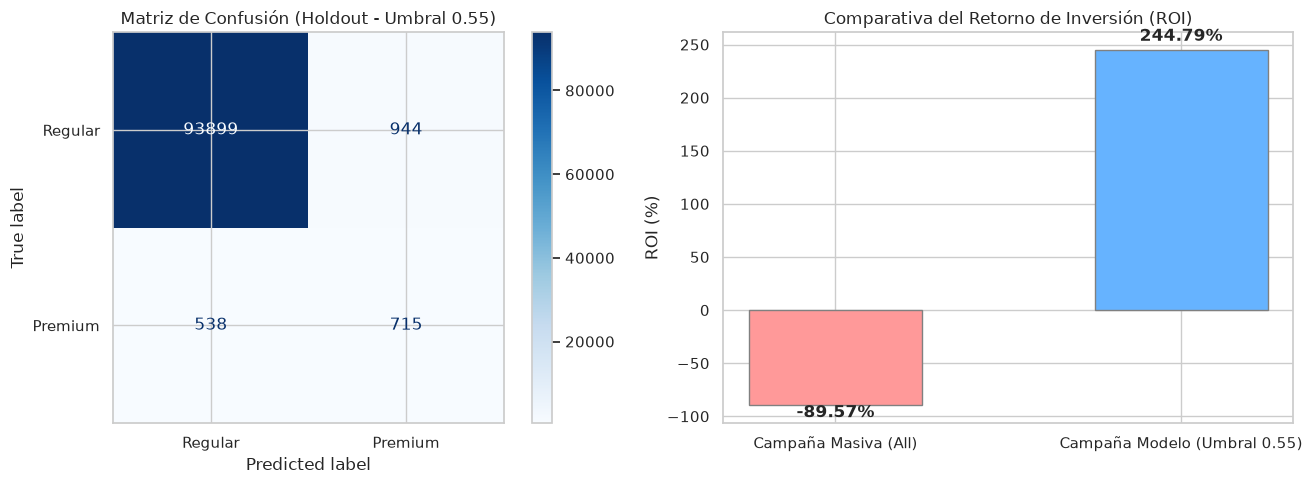

Gráfico guardado en: /home/gerick/Documents/MIADAS/miadas_mod_13_scrum/reports/figures/sprint_04_holdout_evaluation_roi.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Matriz de Confusión en Holdout
ConfusionMatrixDisplay.from_predictions(
    y_holdout, 
    preds_holdout_55, 
    display_labels=['Regular', 'Premium'], 
    cmap='Blues', 
    ax=axes[0]
)
axes[0].set_title('Matriz de Confusión (Holdout - Umbral 0.55)')

# 2. Comparación de ROI por Estrategia
strategies = ['Campaña Masiva (All)', 'Campaña Modelo (Umbral 0.55)']
rois = [roi_all, roi_pred]
colors = ['#ff9999', '#66b3ff']

bars = axes[1].bar(strategies, rois, color=colors, edgecolor='grey', width=0.5)
axes[1].set_ylabel('ROI (%)')
axes[1].set_title('Comparativa del Retorno de Inversión (ROI)')

# Añadir etiquetas en las barras
for bar in bars:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2.0, yval + (5 if yval >= 0 else -15), f'{yval:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
fig_path = FIGURES_DIR / 'sprint_04_holdout_evaluation_roi.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Gráfico guardado en: {fig_path}')